# MLP Classifier

**Architecture:** 3 layer MLP (2 hidden layers of 16 units each, ReLU), input 65 features, output 5 classes (`car`, `large_vehicle`, `two_wheeler`, `pedestrian`, `pedestrian_group`; bus merged into large_vehicle, `Design_Decisions.md` decision 1's final resolution).

**Feature design:** per instance histogram encoding. `rcs`, `vr_compensated`, `x_rel`, `y_rel` each binned into N_BINS=16 fraction of points per bin columns (64 dims total), plus `doppler_spread` appended unbinned (1 dim), for 65 dims total. Bin edges use the 1st to 99th percentile range, fit on train only and reused unchanged for val/test.

**Training:** Adam optimizer, class weighted cross entropy loss (weight = max class count / class count). LEARNING_RATE=4e-5, EPOCHS=50, BATCH_SIZE=128, RANDOM_STATE=0.

**Data:** fixed sequence grouped train/val/test split.

Full writeup: `MLP_Decisions_and_Findings.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from taxonomy_separability import add_relative_features
from mlp_classifier import (
    apply_mlp_class_groups,
    run_training,
    evaluate_val_metrics,
    plot_training_curves,
    N_BINS,
    HIDDEN_DIM,
    LEARNING_RATE,
    EPOCHS,
    BATCH_SIZE,
)

## Build features

In [2]:
df = build_and_save_points_table()
df = add_relative_features(df)
df = apply_mlp_class_groups(df)

/home/bruno/radar_machine_learning_ws/results/data/points_table.parquet already covers exactly the requested sequences, skipping build


## Batch size and learning rate

Batch size affects whether rare classes contribute to each gradient update. bus makes up only 1.9% of the 358,210 train instances (vs. 42.8% for car); at that frequency, bus is absent from 54% of batches at bs=32 and 30% at bs=64.

**Decision:** use batch_size=128, the smallest candidate keeping every class's miss probability below 10%.

Scale the learning rate accordingly:

```
lr = 1e-5 × (128 / 32) = 4e-5
```

This follows the linear scaling rule and avoids slowing training through both larger batches and a reduced learning rate.

See `MLP_Decisions_and_Findings.md` section 1 and `scripts/batch_size_selection.py`.

## Train (cached)

3-layer MLP (65 -> 16 -> 16 -> 5) on the histogram-encoded feature vector, class-weighted cross-entropy, Adam. Config: N_BINS=16, HIDDEN_DIM=16, LEARNING_RATE=4e-5, EPOCHS=50, BATCH_SIZE=128. `run_training` loads the cached model/history if this exact config was already run - it does not retrain. Bus merged into large_vehicle (mlp_classifier.py's default taxonomy); the original, bus-separate taxonomy is kept for reference below.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_training_curves.png


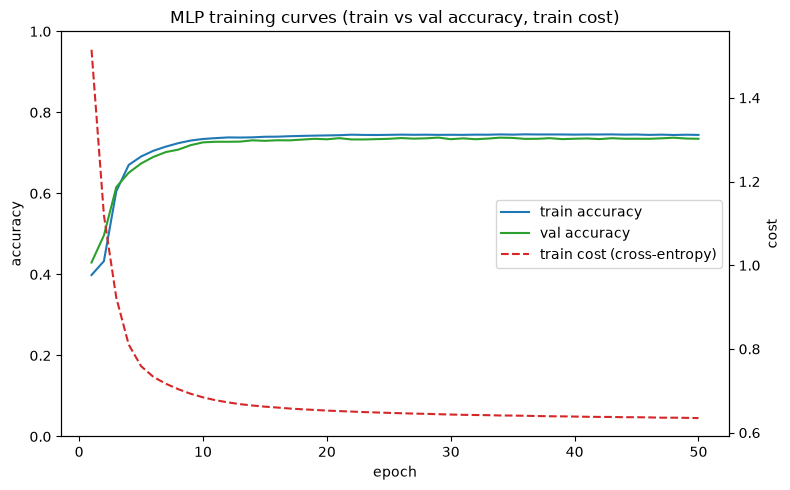

In [3]:
# uses cached model + history if EPOCHS/BATCH_SIZE/LEARNING_RATE match a prior run - no retraining
# plots train vs val accuracy and train cost, from the cached history (no retraining)
model, history, X_test, y_test = run_training(df)

## Validation metrics (cached)

Per-class precision/recall/f1, confusion matrix, and a precision/recall/f1 bar chart - computed from the cached model only, never retrains.

/home/bruno/radar_machine_learning_ws/results/mlp/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.937   0.784  0.854    31055
large_vehicle         0.719   0.797  0.756     6247
two_wheeler           0.475   0.545  0.508     4629
pedestrian            0.534   0.944  0.682    11325
pedestrian_group      0.754   0.544  0.632    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/mlp_precision_recall_f1.png


,precision,recall,f1,support
car,0.937115,0.784093,0.853802,31055
large_vehicle,0.719491,0.796542,0.756059,6247
two_wheeler,0.475302,0.544610,0.507601,4629
pedestrian,0.533806,0.943929,0.681956,11325
pedestrian_group,0.754346,0.544238,0.632295,17858


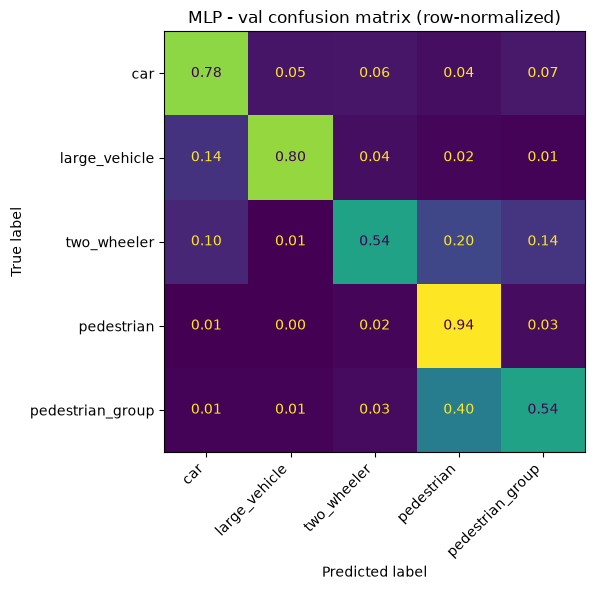

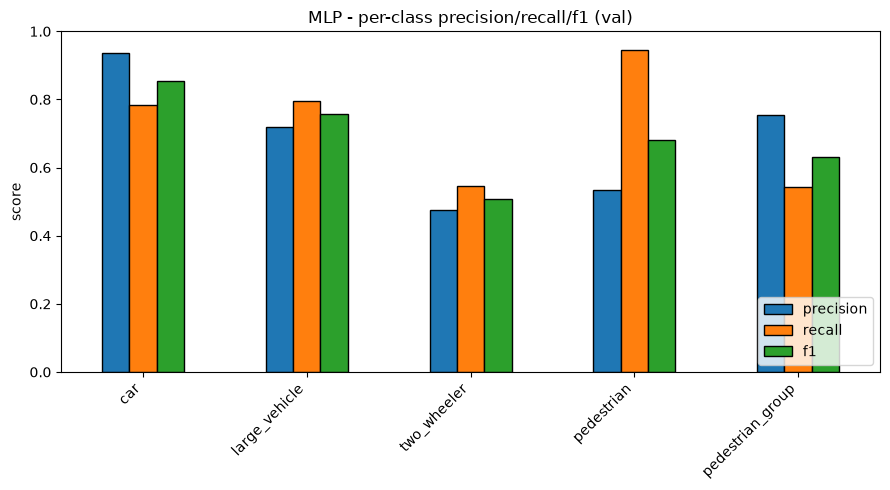

In [4]:
metrics_df, cm_fig, bar_fig = evaluate_val_metrics(df)
metrics_df

## Confusion matrix findings (epochs=50, original bus-separate taxonomy, historical)

This is the confusion matrix that motivated merging bus into large_vehicle, from the original 6 class taxonomy (`results/mlp/bus_separate/mlp_confusion_matrix.png`), not the 5 class model trained above. Row-normalized, val set:

- `car`: 73% correct - the most accurate label, and the majority class. 10% confused as `large_vehicle`.
- `large_vehicle`: confused as `car` and `bus`.
- `bus`: confused as `large_vehicle`.
- `two_wheeler`: confused as `pedestrian` and `pedestrian_group`.
- `pedestrian`: recall high.
- `pedestrian_group`: confused a lot into `pedestrian` as expected, given point sparsity (an isolated pedestrian and a sparse group can look similar with few points to work with).

**Cross-check against `MLP_Decisions_and_Findings.md` section 2:** the confusion isn't scattered, it clusters within car/large_vehicle/bus (all "vehicle" classes) and separately within pedestrian/pedestrian_group, rather than spreading across unrelated classes. That pattern reads more like a feature-separability ceiling (the histogram features can't fully tell `bus` and `large_vehicle` apart) than pure gradient starvation. It's also in tension with the starvation story that `bus`'s recall (71%) is *higher* than `two_wheeler`'s (52%), despite `bus` being the far rarer class (1.9% vs 7.0% of train). If rarity/starvation were the dominant driver, that ordering would likely be reversed. This is what motivated the taxonomy experiment below.

Full writeup: `MLP_Decisions_and_Findings.md` section 3.

## Oversampling for bus / epoch count

Increasing training from 50 to 1000 epochs did not improve bus F1; it slightly decreased, while most other classes improved. Validation accuracy also plateaued after roughly 150 to 200 epochs.

This indicates that the problem is gradient starvation rather than insufficient training: bus remains poorly represented in individual batches.

**Decision:** Repeat the training but with bus merged into large_vehicle, as the original labels. Implemented: this is now `mlp_classifier.py`'s default (see Build features / Train above).

**Decision:** retain EPOCHS=50. The additional 950 epochs produced only a small macro-F1 improvement and mostly added training cost and validation noise.

See `MLP_Decisions_and_Findings.md` section 2. 1000-epoch run: `results/mlp/epochs_1000/`.

## Class taxonomy experiment

Does merging bus into large_vehicle (the standing `baseline`, trained above) actually beat the alternatives, run through the same architecture/training config? `bus_separate` is the original, pre-merge taxonomy (6 classes). `truck_separate` undoes the truck merge too (7 classes). Both reuse the fixed split unchanged and are defined in `scripts/mlp_variants.py`.

/home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_training_history.json already matches this config, loading cached model + history


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.935   0.727  0.818    31055
large_vehicle         0.426   0.582  0.492     4752
bus                   0.439   0.710  0.543     1495
two_wheeler           0.489   0.518  0.503     4629
pedestrian            0.552   0.857  0.672    11325
pedestrian_group      0.683   0.595  0.636    17858
Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_confusion_matrix.png


Saved /home/bruno/radar_machine_learning_ws/results/mlp/bus_separate/mlp_precision_recall_f1.png


/home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_training_history.json already matches this config, loading cached model + history
Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_training_curves.png


/home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_val_metrics.json already cached, reusing
per-class precision/recall/f1 (val):
                  precision  recall     f1  support
car                   0.947   0.701  0.806    31055
large_vehicle         0.059   0.297  0.098     1244
truck                 0.523   0.572  0.546     3508
bus                   0.435   0.696  0.535     1495
two_wheeler           0.495   0.530  0.512     4629
pedestrian            0.539   0.931  0.683    11325
pedestrian_group      0.796   0.495  0.610    17858


Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_confusion_matrix.png
Saved /home/bruno/radar_machine_learning_ws/results/mlp/class_taxonomy_experiment/truck_separate/mlp_precision_recall_f1.png


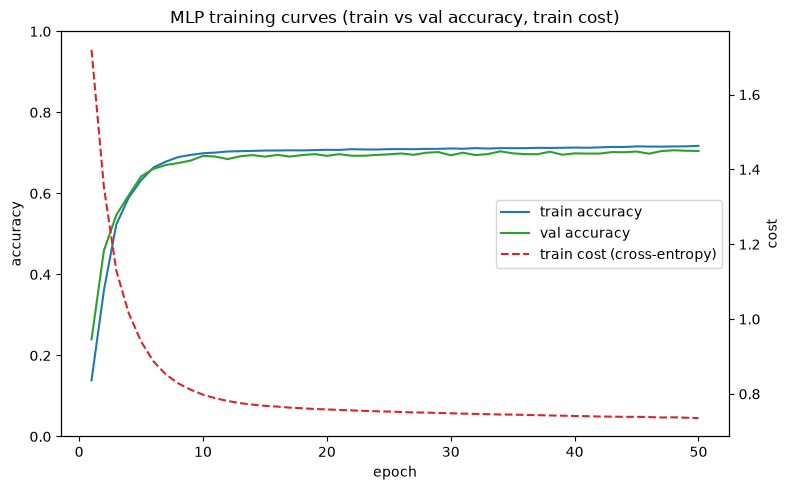

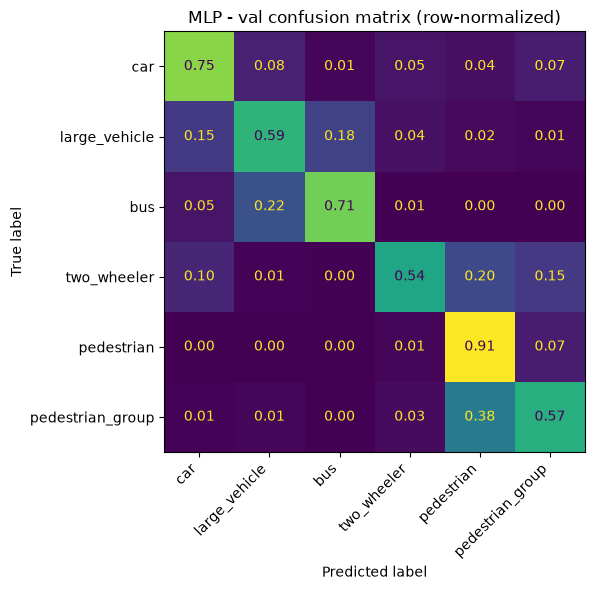

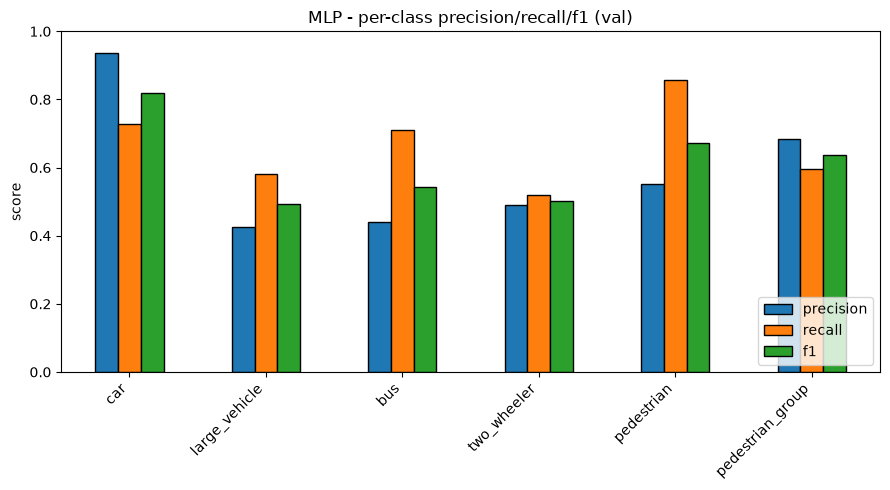

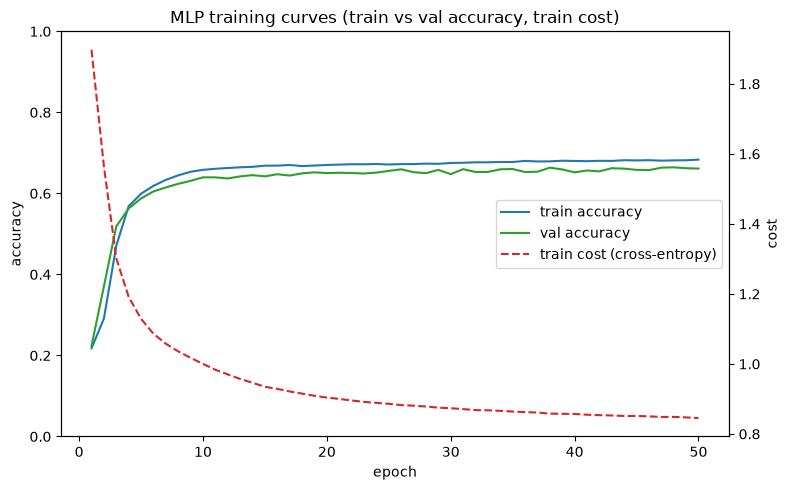

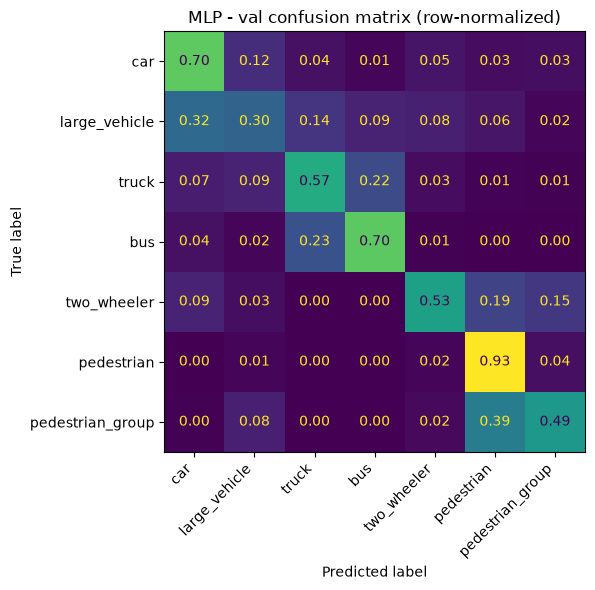

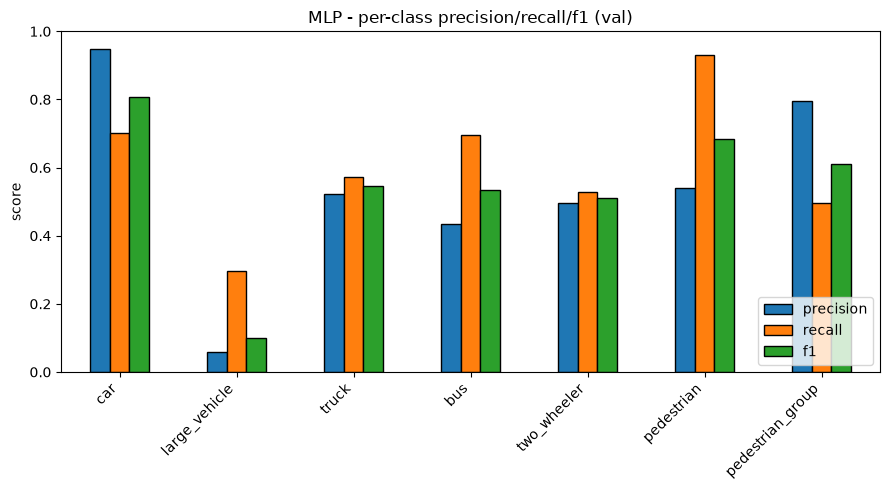

In [5]:
from mlp_variants import run_variant

# both cached, no retraining
_, _, bus_separate_metrics, _, _ = run_variant(df, "bus_separate")
_, _, truck_separate_metrics, _, _ = run_variant(df, "truck_separate")

In [6]:
bus_separate_metrics

,precision,recall,f1,support
car,0.935471,0.727290,0.818348,31055
large_vehicle,0.425758,0.582281,0.491867,4752
bus,0.439156,0.709699,0.542572,1495
two_wheeler,0.489292,0.518254,0.503357,4629
pedestrian,0.551924,0.857395,0.671554,11325
pedestrian_group,0.683142,0.595195,0.636143,17858


In [7]:
truck_separate_metrics

,precision,recall,f1,support
car,0.947199,0.701272,0.805891,31055
large_vehicle,0.058955,0.297428,0.098404,1244
truck,0.522816,0.571551,0.546098,3508
bus,0.434656,0.696321,0.535219,1495
two_wheeler,0.495253,0.529704,0.511900,4629
pedestrian,0.538926,0.930949,0.682660,11325
pedestrian_group,0.796073,0.494904,0.610359,17858


Macro F1: `bus_separate` (original 6 classes) 0.611, `baseline`/bus merged (5 classes) 0.686, `truck_separate` (7 classes) 0.541.

Bus merged (now `baseline`): folding `bus` into `large_vehicle` raises the combined class to F1=0.756, above either `bus` (0.543) or `large_vehicle` (0.492) alone in `bus_separate`. Supports merging `bus` in, extending decision 1's logic, and is why it's now the standing model.

`truck_separate`: splitting `truck` back out leaves pure `large_vehicle` at only 1,292 train instances, and it becomes nearly unusable (F1=0.098). Confirms decision 1's `truck` merge was correct.

Full writeup: `MLP_Decisions_and_Findings.md` section 4.